# Galac_MFCRs
This simulation is dedicated to the propagation of cosmic rays in a bit more complex models of galactic magnetic fields. I based it in the ASS and BSS models, and used it to create tractory and escape time graphs, besides an output file with data to create a deflection map using ROOT. 

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
from mpl_toolkits.mplot3d.art3d import Line3DCollection

E_CHARGE = 1.602176634e-19 #C
C_LIGHT = 299792458.0 #m/s
KPC_TO_M = 3.086e19 #m/kpc
S_TO_YEARS = 3.16888e-8 #yrs/s
MICROGAUSS_TO_TESLA = 1.0e-10 #T/muG
PROTON_MASS = 1.67262192369e-27 #kg
ATOMIC_MASS_UNIT = 1.66053906660e-27 #kg

ASS = 0
BSS = 1

In [9]:
@njit
def mod3(v):
    return np.sqrt(v[0] * v[0] + v[1] * v[1] + v[2] * v[2])

@njit
def random_direction():
    phi = 2.0 * np.pi * np.random.random()
    cos_theta = 2.0 * np.random.random() - 1.0
    sin_theta = np.sqrt(1.0 - cos_theta * cos_theta)
    return np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
        cos_theta,
    ])

@njit
def rel_mass_ultrarelativistic(E, m):
    return E * E_CHARGE / (C_LIGHT * C_LIGHT)

@njit
def energy_to_velocity_nb(E, m, direction):
    energy_joules = E * E_CHARGE
    term = m * C_LIGHT * C_LIGHT / energy_joules
    if term >= 1.0:
        raise ValueError("A energia deve ser maior que a energia de repouso da partícula.")
    speed = C_LIGHT * np.sqrt(1.0 - term * term)
    norm = mod3(direction)
    if norm == 0.0:
        raise ValueError("A direção inicial não pode ter módulo zero.")
    return speed * direction / norm

@njit
def b_galactic_nb(r_kpc, field_type):
    e0 = 10.55
    pitch = -10.0 * np.pi / 180.0
    beta = 1.0 / np.tan(pitch)
    rho = mod3(r_kpc)
    rho1 = 2.0
    solar_radius = 8.5
    theta = np.arctan2(r_kpc[1], r_kpc[0])
    if rho == 0.0:
        amplitude = 0.0
    else:
        base = 3.0 * solar_radius * np.tanh(rho / rho1) ** 3 / rho
        phase = theta - beta * np.log(rho / e0)
        if field_type == ASS:
            amplitude = base * np.cos(phase) ** 2
        else:
            amplitude = base * np.cos(phase)
    b_rho = amplitude * np.sin(pitch)
    b_theta = amplitude * np.cos(pitch)
    return np.array([
        (b_rho * np.cos(theta) - b_theta * np.sin(theta)) * MICROGAUSS_TO_TESLA,
        (b_rho * np.sin(theta) + b_theta * np.cos(theta)) * MICROGAUSS_TO_TESLA,
        0.0,
    ])

@njit
def lorentz_acceleration_nb(q, m_rel, v, B):
    return np.array([
        q * (v[1] * B[2] - v[2] * B[1]) / m_rel,
        q * (v[2] * B[0] - v[0] * B[2]) / m_rel,
        q * (v[0] * B[1] - v[1] * B[0]) / m_rel,
    ])

@njit
def velocity_new_euler_nb(v, a, dt):
    v_temp = v + a * dt
    norm_temp = mod3(v_temp)
    if norm_temp == 0.0:
        return v.copy()
    return mod3(v) * v_temp / norm_temp

In [10]:
@njit
def main_galactic_kernel_nb(q, m, r0_kpc, v0, E, steps, escape_mode, field_type, save_every):
    m_rel = rel_mass_ultrarelativistic(E, m)
    r = r0_kpc * KPC_TO_M
    v = v0.copy()
    initial_B = b_galactic_nb(r0_kpc, field_type)
    initial_B_norm = mod3(initial_B)
    if initial_B_norm == 0.0:
        raise ValueError("O campo magnético inicial não pode ser nulo.")
    period = 2.0 * np.pi * m_rel / (np.abs(q) * initial_B_norm)
    if E < 1.0e15:
        dt = period / 100.0
    else:
        dt = period / 1000.0
    if save_every < 1:
        save_every = 1
    max_points = steps // save_every + 2
    positions = np.empty((max_points, 3), dtype=np.float64)
    times = np.empty(max_points, dtype=np.float64)
    escape_velocity = np.empty(3, dtype=np.float64)
    saved = 0
    escaped = False
    escape_time = np.nan
    for i in range(steps):
        r_old_kpc = r / KPC_TO_M
        z_old = r_old_kpc[2]
        radius_old = np.sqrt(r_old_kpc[0] ** 2 + r_old_kpc[1] ** 2)
        B = b_galactic_nb(r_old_kpc, field_type)
        a = lorentz_acceleration_nb(q, m_rel, v, B)
        v_old = v.copy()
        r_next = r + v_old * dt + 0.5 * a * dt * dt
        r_next_kpc = r_next / KPC_TO_M
        z_new = r_next_kpc[2]
        radius_new = np.sqrt(r_next_kpc[0] ** 2 + r_next_kpc[1] ** 2)
        crossed = False
        fraction = 0.0
        if escape_mode == 0:
            limit = 0.05
            if np.abs(z_old) <= limit and np.abs(z_new) > limit:
                crossed = True
                fraction = (limit - np.abs(z_old)) / (np.abs(z_new) - np.abs(z_old))
        else:
            limit = 24.0
            if radius_old <= limit and radius_new > limit:
                crossed = True
                fraction = (limit - radius_old) / (radius_new - radius_old)
        if crossed:
            positions[saved] = r_old_kpc + fraction * (r_next_kpc - r_old_kpc)
            times[saved] = (i + fraction) * dt * S_TO_YEARS
            escape_velocity = v_old
            escape_time = times[saved]
            saved += 1
            escaped = True
            break
        if i % save_every == 0:
            positions[saved] = r_next_kpc
            times[saved] = (i + 1) * dt * S_TO_YEARS
            saved += 1
        v = velocity_new_euler_nb(v_old, a, dt)
        r = r_next
    return positions[:saved], times[:saved], escape_time, escape_velocity, escaped, dt

def main_galactic_fast(q, m, r0_kpc, v0, E, steps, escape_mode="z", field_type="ASS", save_every=1):
    escape_code = 0 if escape_mode.lower() == "z" else 1
    field_code = ASS if field_type.upper() == "ASS" else BSS
    positions, times, escape_time, escape_velocity, escaped, dt = main_galactic_kernel_nb(
        float(q),
        float(m),
        np.asarray(r0_kpc, dtype=np.float64), 
        np.asarray(v0, dtype=np.float64),
        float(E),
        int(steps),
        escape_code,
        field_code,
        int(save_every),
    )
    df = pd.DataFrame(positions, columns=["x", "y", "z"])
    df["time_years"] = times
    return df, escape_time if escaped else None, escape_velocity.copy() if escaped else None, dt

In [11]:
@njit
def lat_e_long_numba(v):
    x = v[0]
    y = v[1]
    z = v[2]
    r = np.sqrt(x * x + y * y + z * z)
    if r == 0.0:
        return np.nan, np.nan
    lat = np.arcsin(z / r)
    lon = np.arctan2(y, x)
    return lat, lon

def extrair_velocidade_final(v_escapes):
    if v_escapes is None:
        return None
    v_arr = np.asarray(v_escapes, dtype=np.float64)
    if v_arr.ndim == 1 and v_arr.size == 3:
        return v_arr
    if v_arr.ndim == 2 and v_arr.shape[1] == 3:
        return v_arr[-1]
    raise ValueError("Formato inesperado para v_escapes")

In [12]:
def plot_trajectory(df, name):
    #plt.switch_backend('TkAgg') # when this line is enabled it opens a diferent window showing the graph, where you can rotate the figure and zoom in. It doesn't work so well for trajectories with too many points. 
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.plot3D(df['x'], df['y'], df['z'], 'purple')
    x, y, z = df['x'].values, df['y'].values, df['z'].values
    #adding color grading with time
    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(df['time_years'].min(), df['time_years'].max())
    lc = Line3DCollection(segments, cmap='plasma', norm=norm)
    lc.set_array(df['time_years'])
    lc.set_linewidth(2)
    ax.add_collection(lc)
    ax.set_xlabel('x(kpc)')
    ax.set_ylabel('y(kpc)')
    ax.set_zlabel('z(kpc)')
    ax.set_title(f'Trajetória galáctica do {name}')
    cbar = fig.colorbar(lc, ax=ax, pad=0.1)
    cbar.set_label('Tempo (anos)', rotation=270, labelpad=15)
    plt.show()

## Trajectory plots

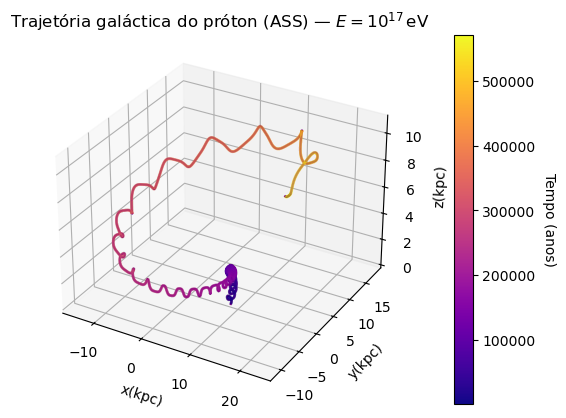

Tempo de escape (anos): 571435.2961006026
Velocidade de escape (m/s): [ 8.62611320e+07 -2.66442976e+08  1.06970442e+08]
Passo temporal (s): 203467738.93710822


In [8]:
q = E_CHARGE
m = PROTON_MASS
E = 1.0e17
r0 = np.array([8.5, 0.0, 0.0])
v0 = energy_to_velocity_nb(E, m, np.array([1.0, 1.0, 1.0]))

df, escape_time_years, escape_velocity, dt = main_galactic_fast(q, m, r0, v0, E, steps=1000000, escape_mode="R", field_type="ASS", save_every=5)

plot_trajectory(df, r"próton (ASS) — $E = 10^{17}\,\mathrm{eV}$")
print("Tempo de escape (anos):", escape_time_years)
print("Velocidade de escape (m/s):", escape_velocity)
print("Passo temporal (s):", dt)

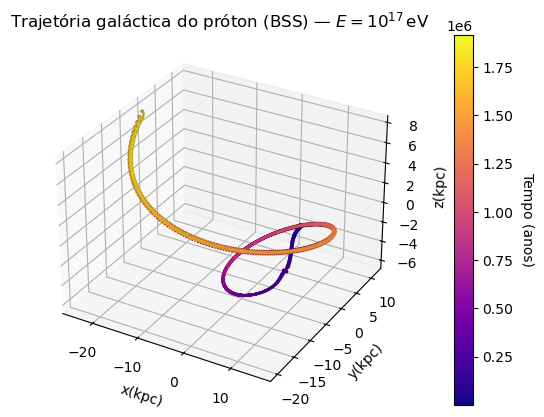

Tempo de escape (anos): 1914954.5157437702
Velocidade de escape (m/s): [-1.73980637e+08  1.12869214e+08 -2.16487405e+08]
Passo temporal (s): 68900358.07523409


In [11]:
q = E_CHARGE
m = PROTON_MASS
E = 1.0e17
r0 = np.array([8.5, 0.0, 0.0])
v0 = energy_to_velocity_nb(E, m, np.array([1.0, 1.0, 1.0]))

df, escape_time_years, escape_velocity, dt = main_galactic_fast(q, m, r0, v0, E, steps=1000000, escape_mode="R", field_type="BSS", save_every=5)

plot_trajectory(df, r"próton (BSS) — $E = 10^{17}\,\mathrm{eV}$")
print("Tempo de escape (anos):", escape_time_years)
print("Velocidade de escape (m/s):", escape_velocity)
print("Passo temporal (s):", dt)

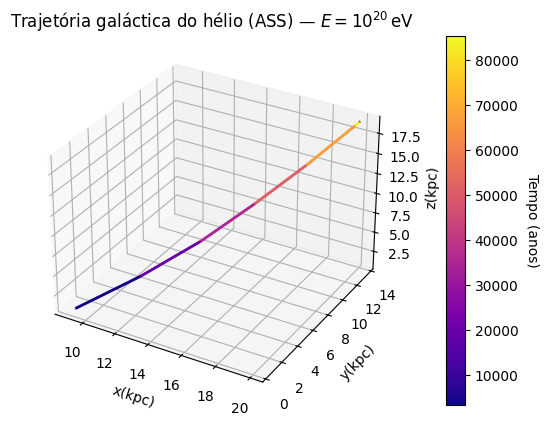

Tempo de escape (anos): 85430.79629733518
Velocidade de escape (m/s): [1.02489398e+08 1.31999951e+08 2.48892455e+08]
Passo temporal (s): 101733869468.5541


In [ ]:
q = 2*E_CHARGE
m = 4*ATOMIC_MASS_UNIT
E = 1.0e20
r0 = np.array([8.5, 0.0, 0.0])
v0 = energy_to_velocity_nb(E, m, np.array([1.0, 1.0, 1.0]))

df, escape_time_years, escape_velocity, dt = main_galactic_fast(q, m, r0, v0, E, steps=1000000, escape_mode="R", field_type="ASS", save_every=5)

plot_trajectory(df, r"hélio (ASS) — $E = 10^{20}\,\mathrm{eV}$")
print("Tempo de escape (anos):", escape_time_years)
print("Velocidade de escape (m/s):", escape_velocity)
print("Passo temporal (s):", dt)

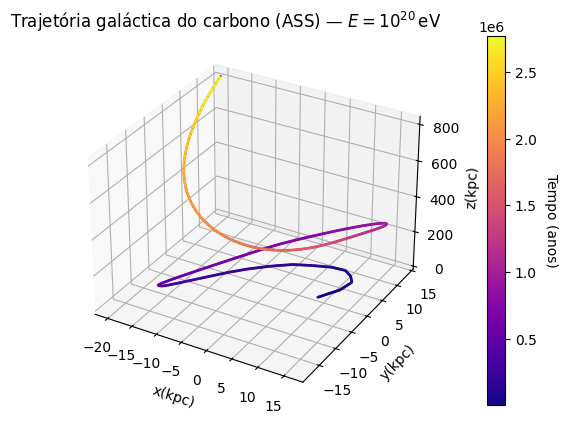

Tempo de escape (anos): 2768356.660419382
Velocidade de escape (m/s): [-8.05416250e+06  5.00703170e+07  2.95471846e+08]
Passo temporal (s): 33911289822.851368


In [ ]:
q = 6*E_CHARGE
m = 12*ATOMIC_MASS_UNIT
E = 1.0e20
r0 = np.array([8.5, 0.0, 0.0])
v0 = energy_to_velocity_nb(E, m, np.array([1.0, 1.0, 1.0]))

df, escape_time_years, escape_velocity, dt = main_galactic_fast(q, m, r0, v0, E, steps=1000000, escape_mode="R", field_type="ASS", save_every=20)

plot_trajectory(df, r"carbono (ASS) — $E = 10^{20}\,\mathrm{eV}$           ")
print("Tempo de escape (anos):", escape_time_years)
print("Velocidade de escape (m/s):", escape_velocity)
print("Passo temporal (s):", dt)

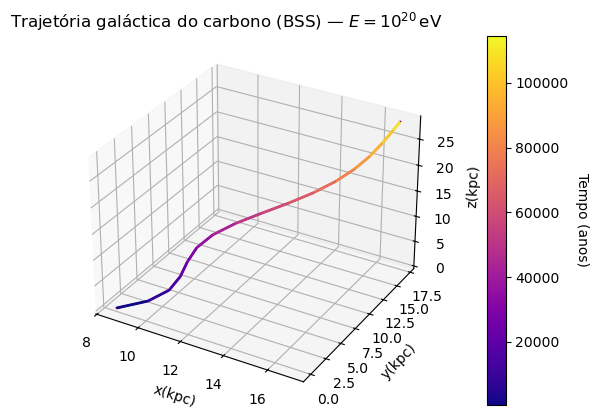

Tempo de escape (anos): 114629.98751742685
Velocidade de escape (m/s): [3.76642208e+07 9.77631211e+07 2.80890186e+08]
Passo temporal (s): 11483393012.539015


In [14]:
q = 6*E_CHARGE
m = 12*ATOMIC_MASS_UNIT
E = 1.0e20
r0 = np.array([8.5, 0.0, 0.0])
v0 = energy_to_velocity_nb(E, m, np.array([1.0, 1.0, 1.0]))

df, escape_time_years, escape_velocity, dt = main_galactic_fast(q, m, r0, v0, E, steps=1000000, escape_mode="R", field_type="BSS", save_every=20)

plot_trajectory(df, r"carbono (BSS) — $E = 10^{20}\,\mathrm{eV}$           ")
print("Tempo de escape (anos):", escape_time_years)
print("Velocidade de escape (m/s):", escape_velocity)
print("Passo temporal (s):", dt)

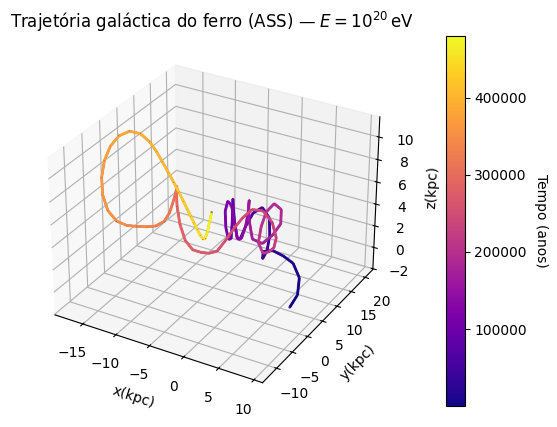

Tempo de escape (anos): 479447.0868644264
Velocidade de escape (m/s): [-4.97826218e+06  2.12344282e+08  2.11567107e+08]
Passo temporal (s): 7825682266.811854


In [ ]:
q = 26*E_CHARGE
m = 56*ATOMIC_MASS_UNIT
E = 1.0e20
r0 = np.array([8.5, 0.0, 0.0])
v0 = energy_to_velocity_nb(E, m, np.array([1.0, 1.0, 1.0]))

df, escape_time_years, escape_velocity, dt = main_galactic_fast(q, m, r0, v0, E, steps=1000000, escape_mode="R", field_type="ASS", save_every=20)

plot_trajectory(df, r"ferro (ASS) — $E = 10^{20}\,\mathrm{eV}$")
print("Tempo de escape (anos):", escape_time_years)
print("Velocidade de escape (m/s):", escape_velocity)
print("Passo temporal (s):", dt)

## Escape Time Plots 

E=1e+17, mean time_years=1840853.6545282793, n=100
E=1e+18, mean time_years=528715.2033132183, n=100
E=1e+19, mean time_years=144532.4473242599, n=100
E=1e+20, mean time_years=102025.64974791661, n=100
E=1e+17, mean time_years=3706976.982989375, n=100
E=1e+18, mean time_years=602277.8045828602, n=100
E=1e+19, mean time_years=318884.9481157408, n=100
E=1e+20, mean time_years=124299.42918754992, n=100
E=1e+17, mean time_years=12169456.943883639, n=100
E=1e+18, mean time_years=1091056.9096600958, n=100
E=1e+19, mean time_years=533291.4440282995, n=100
E=1e+20, mean time_years=118534.82627035293, n=100
E=1e+17, no escape
E=1e+18, mean time_years=4963996.287824926, n=100
E=1e+19, mean time_years=680019.5788374435, n=100
E=1e+20, mean time_years=489446.8792820892, n=100


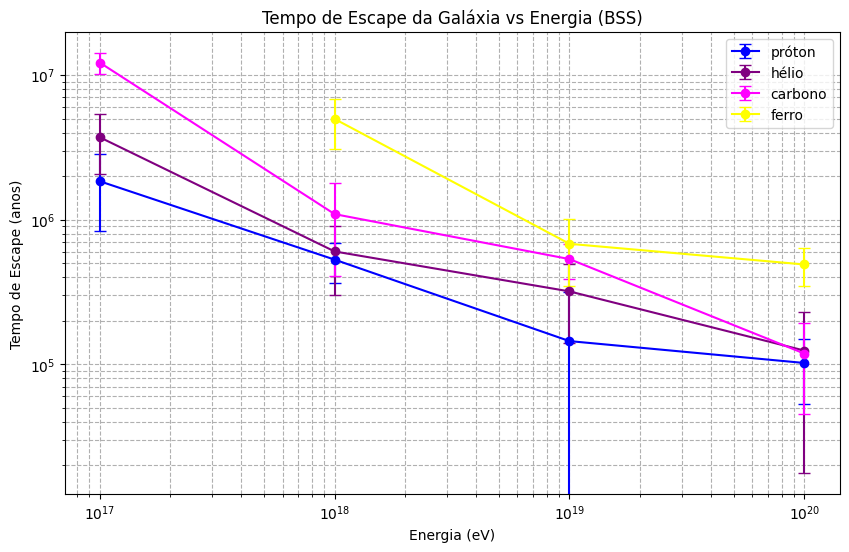

In [ ]:
masses = [PROTON_MASS, 4*ATOMIC_MASS_UNIT, 12*ATOMIC_MASS_UNIT, 56*ATOMIC_MASS_UNIT]
charges = [1.0*E_CHARGE, 2.0*E_CHARGE, 6.0*E_CHARGE, 26*E_CHARGE]
particle_names = ["próton", "hélio", "carbono", "ferro"]
colors = ["blue", "purple", "magenta", "yellow"]

Energies = [1e17, 1e18, 1e19, 1e20]


r0 = np.array([8.5, 0.0, 0.0], dtype=np.float64)

plt.figure(figsize=(10, 6))

for idx, m in enumerate(masses):
    q = charges[idx]
    name = particle_names[idx]
    color = colors[idx]

    escape_times = []

    for E in Energies:
        energy_times = []

        for j in range(100):
            direc_v0 = random_direction()
            v0 = energy_to_velocity_nb(E, m, direc_v0)
            v0 = np.asarray(v0, dtype=np.float64)

            df, time_years, v_escapes, dt = main_galactic_fast(
                q, m, r0, v0, E,
                steps=80000000,
                escape_mode="R",
                field_type="BSS", #alternate here between the ASS and BSS models
                save_every=20
            )

            if time_years is not None and v_escapes is not None:
                energy_times.append(time_years)

        if energy_times:
            t_mean = np.mean(energy_times)
            n = len(energy_times)
            inc_t = np.std(energy_times)

            escape_times.append((E, t_mean, inc_t))
            print(f"E={E}, mean time_years={t_mean}, n={n}")
        else:
            print(f"E={E}, no escape")

    df_results = pd.DataFrame(
        escape_times,
        columns=["Energy", "t_escape", "inc_t"]
    )

    if not df_results.empty:
        plt.errorbar(
            df_results["Energy"],
            df_results["t_escape"],
            yerr=df_results["inc_t"],
            fmt="o-",
            color=color,
            capsize=4,
            label=name
        )
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energia (eV)")
plt.ylabel("Tempo de Escape (anos)")
plt.title(f"Tempo de Escape da Galáxia vs Energia (BSS)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

## Output file for ROOT - creation of deflection maps

In [15]:
def angulo_deflexao_total(v_inicial, v_final):
    v_inicial = np.asarray(v_inicial, dtype=np.float64)
    v_final = np.asarray(v_final, dtype=np.float64)

    norma_inicial = np.linalg.norm(v_inicial)
    norma_final = np.linalg.norm(v_final)

    if norma_inicial == 0.0 or norma_final == 0.0:
        return np.nan

    cos_angulo = np.dot(v_inicial, v_final) / (
        norma_inicial * norma_final
    )

    cos_angulo = np.clip(cos_angulo, -1.0, 1.0)

    return float(
        np.degrees(
            np.arccos(cos_angulo)
        )
    )



masses = [PROTON_MASS]
charges = [E_CHARGE]
particle_names = ["próton"]
energies = [1.0e20]
r0 = np.array([8.5, 0.0, 0.0], dtype=np.float64)
number_of_simulations = 1000
steps = 10000000
escape_mode = "R"
field_type = "ASS"
save_every = 20
output_file = "lat_long_velocidades_ROOT_ASS_P_20.csv"
deflection_output_file = "angulos_deflexao_ROOT_BSS_C.txt"

latlong_data = []
deflection_data = []
escape_results = []

for idx, m in enumerate(masses):
    q = charges[idx]
    name = particle_names[idx]

    for E in energies:
        energy_times = []

        for sim in range(number_of_simulations):
            v0 = energy_to_velocity_nb(E, m, random_direction())
            lat0, lon0 = lat_e_long_numba(v0)

            df, time_years, v_escapes, dt = main_galactic_fast(
                q,
                m,
                r0,
                v0,
                E,
                steps=steps,
                escape_mode=escape_mode,
                field_type=field_type,
                save_every=save_every,
            )

            if time_years is not None and v_escapes is not None:
                energy_times.append(time_years)
                v_final = extrair_velocidade_final(v_escapes)
                latf, lonf = lat_e_long_numba(v_final)
                deflection_deg = angulo_deflexao_total(v0, v_final)
                if np.isnan(deflection_deg):
                    continue
                latlong_data.append([lat0, lon0, 0, E, sim, time_years])
                latlong_data.append([latf, lonf, 1, E, sim, time_years])
                deflection_data.append([E,sim,deflection_deg,time_years])
        if energy_times:
            escape_results.append([
                name,
                E,
                np.mean(energy_times),
                np.std(energy_times),
                len(energy_times),
            ])
            print(f"E={E:.1e}, mean time_years={np.mean(energy_times)}, n={len(energy_times)}")
        else:
            print(f"E={E:.1e}, no escape")

df_latlong = pd.DataFrame(
    latlong_data,
    columns=["lat", "lon", "tipo", "energy", "sim", "time_years"],
)

df_escape = pd.DataFrame(
    escape_results,
    columns=["particle", "Energy", "t_escape", "inc_t", "n"],
)

df_latlong.to_csv(output_file, index=False)

df_deflection = pd.DataFrame(
    deflection_data,
    columns=["energy","sim","deflection_deg","time_years"],
)

df_deflection.to_csv(
    deflection_output_file,
    index=False,
    header=False,
    sep=" ",
    float_format="%.10e",
)
print(df_latlong.head())
print(f"Arquivo salvo: {output_file}")
print(os.path.abspath(output_file))
print(len(df_latlong))

E=1.0e+20, mean time_years=126169.2975125602, n=1000
        lat       lon  tipo        energy  sim     time_years
0 -1.457146 -0.467820     0  1.000000e+20    0  177709.092803
1 -1.186132 -0.039929     1  1.000000e+20    0  177709.092803
2 -0.566168 -2.961715     0  1.000000e+20    1  127327.071776
3 -0.510608 -2.870288     1  1.000000e+20    1  127327.071776
4  0.467337 -1.330980     0  1.000000e+20    2   78694.439558
Arquivo salvo: lat_long_velocidades_ROOT_ASS_P_20.csv
c:\Users\raiss\Downloads\lat_long_velocidades_ROOT_ASS_P_20.csv
2000


-> Using the data sets obtained above, I've created histograms and deflection maps using ROOT. In the next cell, the data I'll use is taken from these histograms.

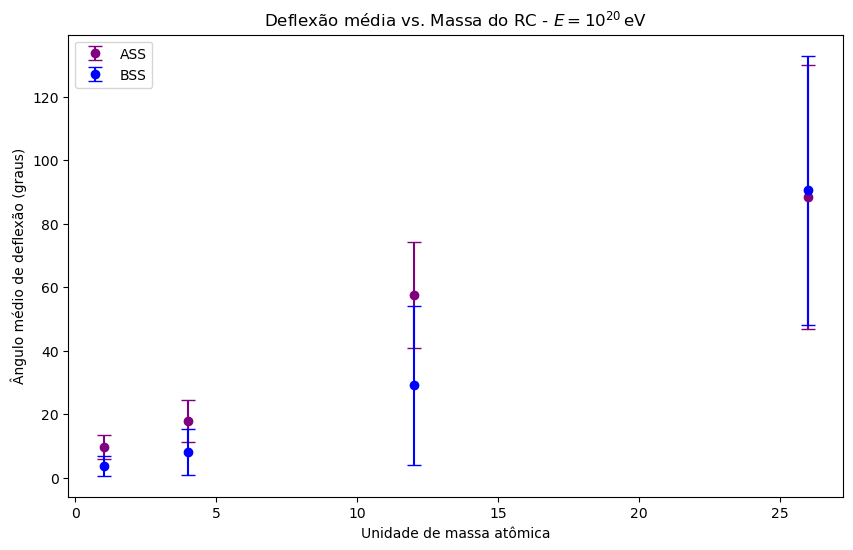

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

masses = [1, 4, 12, 26]

mean_ASS = [9.623, 17.9, 57.64, 88.53]
mean_BSS = [3.768, 8.113, 29.06, 90.58]

std_dev_ASS = [3.662, 6.679, 16.67, 41.54]
std_dev_BSS = [3.163, 7.248, 25.16, 42.4]

x = masses
y1 = mean_ASS
y2 = mean_BSS

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(x, y1, yerr=std_dev_ASS, fmt='o', capsize=5, label='ASS', color='purple')
ax.errorbar(x, y2, yerr=std_dev_BSS, fmt='o', capsize=5, label='BSS', color='blue')
ax.set_xlabel('Unidade de massa atômica')
ax.set_ylabel('Ângulo médio de deflexão (graus)')
ax.set_title(r'Deflexão média vs. Massa do RC - $E = 10^{20}\,\mathrm{eV}$')
ax.legend()

plt.show()